Maciek Gilecki 173142 Lab 4

In [25]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
mode = "rgb_array"
if mode == "None":
    mode = None


(12, 5, 0)


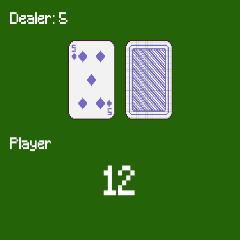

In [26]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [27]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [28]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [29]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((22, 5, 0), -1.0, True, False)

In [30]:
env.close()

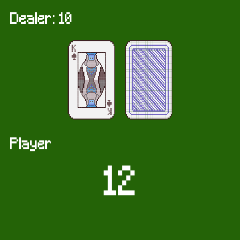

nagroda = -1.0, liczba punktów graczy = 12


In [31]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [32]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

0, obserwation, (20, 2, 0), 1.0, True
nagroda = 1.0, liczba punktów gracza = 20, liczba punktów przeciwnika = 2


Taxi

409


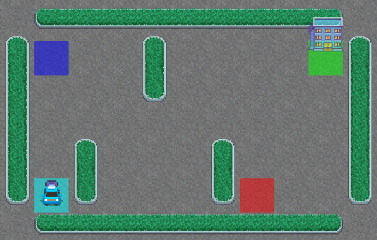

In [33]:
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode='rgb_array') # rgb_array

#observation, info = env.reset()
observation, _ = env.reset()
print(f"{observation}")
img = env.render();
w, h, _ = img.shape
ratio = h/w                 # !!!
new_w, new_h = int(ratio* 240), 240 # !!!
cv2_imshow( cv2.resize(img, (new_w, new_h)) ) # OpenCV
#env.close()

In [34]:
env.action_space, env.observation_space

(Discrete(6), Discrete(500))

In [35]:
def flatten_state(env, obs):
    if isinstance(obs, int): # dla taxi
        return obs
    else: # dla blackjack
        ans = obs[0];
        prod = 1;
        for n in range(1, len(obs)):
            prod *= env.observation_space[n-1].n
            ans += prod*obs[n]
        return ans

def max_states(env, obs):
    prod = 1
    if isinstance(env.observation_space, gym.spaces.tuple.Tuple):
        for i in range(len(env.observation_space)):
            prod *= env.observation_space[i].n
    else:
        prod = env.observation_space.n
    return prod

# test
observation, _ = env.reset()
print(observation)
flatten_state(env, observation), max_states(env, observation)


# [ info ] 389


389

In [36]:
def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    # implementacja Q-learning --- do zrobienia
    action = env.action_space.sample() # losowo wybrana akcja # !!!!!!!!!!!!!!!!
    #print(f"{action}, {observation}, ", end='')
    observation, reward, terminated, truncated, info = env.step( action )
    #print(f"{observation}, {reward}, {terminated}")
  #print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")
  return reward
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)

rewards = 0
draws = 0
for i in range(1000):
  tmp = round(nowa_gra_sample(env))
  if tmp > 0:
    rewards += 1
  elif tmp == 0:
    draws += 1
# rewards
print(f"{100*rewards / 1000.0}%, {rewards}, {draws}, {1000-(rewards+draws)}")


27.3%, 273, 44, 683


In [37]:
env.observation_space, 32*11*2, env.action_space.n

(Tuple(Discrete(32), Discrete(11), Discrete(2)), 704, np.int64(2))

In [38]:
def q_learning(env, Q_table, episodes=1000, alpha=0.5, gamma=0.9, epsilon=0.8):
    rewards = []
    steps = []
    for episode in range(episodes):
        step = 0  # reset per episode
        episode_reward = 0
        observation, info = env.reset()
        terminated = False
        truncated = False
        while (not terminated) and (not truncated):
            state = flatten_state(env, observation)
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q_table[state, :])

            observation, reward, terminated, truncated, info = env.step(action)
            next_state = flatten_state(env, observation)
            episode_reward += reward

            Q_table[state, action] = (1 - alpha) * Q_table[state, action] \n                + alpha * (reward + gamma * np.max(Q_table[next_state, :]))

            step += 1
            state = next_state

        rewards.append(episode_reward)
        steps.append(step)
        epsilon -= epsilon / episodes

        # Progress bar
        print(f"\r{100*episode//(episodes-1):>3}%|", end="")
        for j in range(10):
            if 10*episode//(episodes-1) % 11 > j:
                print("#", end="")
            else:
                print(" ", end="")
        print(f"| {episode:3}, {epsilon:.3f}, {episode_reward:5}, {step:5}", end="")

    return Q_table, rewards, steps


In [39]:
env = gym.make("Taxi-v4", render_mode=None)
observation, info = env.reset()
prod = max_states(env, observation)
Q_table = np.zeros([prod, env.action_space.n])
Q_table, rewards, steps = q_learning(env, Q_table, episodes=2000, alpha=0.1, gamma=0.6, epsilon=0.1)
env.close()


Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
# [ info ] 408
# [ info ] 308
# [ info ] 308
# [ info ] 308
# [ info ] 308
# [ info ] 408
# [ info ] 408
# [ info ] 408
# [ info ] 408
# [ info ] 416
# [ info ] 416
# [ info ] 316
# [ info ] 316
# [ info ] 416
# [ info ] 416
# [ info ] 316
# [ info ] 316
# [ info ] 316
# [ info ] 316
# [ info ] 216
# [ info ] 216
# [ info ] 116
# [ info ] 116
# [ info ] 16
# [ info ] 16
# [ info ] 16
# [ info ] 16
# [ info ] 0
 88%|########  | 881, 0.331,   -16, 54257# [ info ] 392
# [ info ] 492
# [ info ] 492
# [ info ] 472
# [ info ] 472
# [ info ] 372
# [ info ] 372
# [ info ] 372
# [ info ] 372
# [ info ] 472
# [ info ] 472
# [ info ] 492
# [ info ] 492
# [ info ] 472
# [ info ] 472
# [ info ] 476
# [ info ] 476
# [ info ] 476
# [ info ] 476
# [ info ] 376
# [ info ] 376
# [ info ] 376
# [ info ] 376
# [ info ] 396
# [ info ] 396
# [ info ] 376
# [ info ] 376
# [ info ] 376
# [ info ] 376
# [ info ] 276
# [ info ] 276
# [ info ] 176


In [40]:
print(*Q_table)

[0. 0. 0. 0. 0. 0.] [-0.75753512  0.3686455  -0.70753149  0.347235    1.62261467 -8.57119151] [ 3.7047259   5.56316629  4.18375785  5.91133543  7.7147     -3.05901601] [-4.32439287  1.52541446 -3.05775145  1.42436656  2.9140163  -8.02866526] [ -5.9690707   -5.96373505  -6.1407692   -6.04661413 -14.67363013
 -14.72678031] [0. 0. 0. 0. 0. 0.] [ -6.62301813  -6.65352918  -6.61012634  -6.53512584 -14.20444297
 -14.77120775] [ -5.0423209   -5.44080987  -5.41221071  -5.38487841 -14.48832798
 -14.31241678] [  1.50949054  -4.99209737  -5.3073008   -4.9139257  -13.70233952
 -11.07812211] [ -2.41138843  -5.33216088  -4.88039708  -4.71274027 -12.69676908
 -12.47026378] [0. 0. 0. 0. 0. 0.] [ -5.40682437  -5.39716889  -5.51584116  -5.47528193 -14.46300337
 -14.25410784] [ -6.22692727  -6.42493529  -5.76082911  -6.40080526 -15.04755878
 -15.3717584 ] [ -4.23802124  -5.27141563  -5.29775614  -5.27868465 -13.68252278
 -13.96082417] [ -6.43663506  -6.42624663  -6.44979622  -6.45994867 -15.23725662
 -15

In [41]:
def nowa_gra_q_table(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False

    # render pierwszej klatki
    img = env.render()
    w, h, _ = img.shape
    ratio = h / w
    new_w, new_h = int(ratio * 240), 240
    cv2_imshow(cv2.resize(img, (new_w, new_h)))

    while (not terminated) and (not truncated):
        state = flatten_state(env, observation)
        action = np.argmax(Q_table[state, :])
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        output.clear(wait=True)
        img = env.render()
        cv2_imshow(cv2.resize(img, (new_w, new_h)))
        time.sleep(0.5)
    return episode_reward

env2 = gym.make("Taxi-v4", render_mode=mode)
print(nowa_gra_q_table(env2))


Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
# [ info ] 177
# [ info ] 77
# [ info ] 97
# [ info ] 241
# [ info ] 221
# [ info ] 201
# [ info ] 101
# [ info ] 1
# [ info ] 17
# [ info ] 117
# [ info ] 217
# [ info ] 237
# [ info ] 257
# [ info ] 277
# [ info ] 177
# [ info ] 77
# [ info ] 97
# [ info ] 7
# [ info ] 107
# [ info ] 127
# [ info ] 227
# [ info ] 247
# [ info ] 267
# [ info ] 167
# [ info ] 67
# [ info ] 87
# [ info ] 99
# [ info ] 199
# [ info ] 299
# [ info ] 399
# [ info ] 379
# [ info ] 479
# [ info ] 112
# [ info ] 212
# [ info ] 232
# [ info ] 252
# [ info ] 272
# [ info ] 372
# [ info ] 472
# [ info ] 476
# [ info ] 376
# [ info ] 276
# [ info ] 256
# [ info ] 236
# [ info ] 216
# [ info ] 116
# [ info ] 16
# [ info ] 431
# [ info ] 331
# [ info ] 231
# [ info ] 211
# [ info ] 311
# [ info ] 411
# [ info ] 419
# [ info ] 319
# [ info ] 219
# [ info ] 239
# [ info ] 259
# [ info ] 279
# [ info ] 379
# [ info ] 479
# [ info ] 307
# [ info ] 207
# [

In [ ]:
# Wykres 1: nagrody w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(rewards)
plt.title("Rewards per episode")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.tight_layout()
plt.show()


In [ ]:
# Wykres 2: liczba kroków w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(steps)
plt.title("Steps per episode")
plt.xlabel("Epizod")
plt.ylabel("Kroki")
plt.tight_layout()
plt.show()


## Podsumowanie / Wnioski

W ramach laboratorium zaimplementowano algorytm Q-learning dla środowisk Blackjack oraz Taxi z biblioteki Gymnasium.

**Blackjack:** Losowa polityka wygrywa ok. 40% partii. Algorytm Q-learning stopniowo optymalizuje Q-table, jednak środowisko jest trudne — duży wpływ losowości (tasowanie kart) ogranicza przewagę wyuczonej strategii.

**Taxi:** Środowisko deterministyczne, co sprzyja nauce. Po 2000 epizodach agent poprawnie odbiera i dostarcza pasażera, a wykres rewards(episode) wyraźnie rośnie ku wartości ~8, zaś steps(episode) maleje — agent uczy się krótszych tras. Zmniejszanie epsilon w trakcie treningu (eksploracja → eksploatacja) widocznie przyspiesza zbieżność.

**Wnioski:** Q-learning sprawdza się dobrze w dyskretnych, niezbyt dużych przestrzeniach stanów. Dla środowisk ciągłych (np. CarRacing) wymagałby dyskretyzacji lub zastąpienia przez Deep Q-Network (DQN).
